In [1]:
library(dplyr)

Warning message:
“package ‘dplyr’ was built under R version 4.3.2”

Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




In [ ]:
CA1_path <- "./03_Histone/Paired-Tag_DMR/output/04_H3K4me3_Allsubclass/CA1/"
CA1_files <- list.files(path = CA1_path, pattern = "\\.tmp$", full.names = TRUE)
CA1_files

[1] "/share/analysisdata/Methyl/public/TSO/yangfa/Re_analyze/03_Histone/Paired-Tag_DMR/output/04_H3K4me3_Allsubclass/CA1//Paired-Tag_H3K4me3_FC_CT.mm10.tmp"     
 [2] "/share/analysisdata/Methyl/public/TSO/yangfa/Re_analyze/03_Histone/Paired-Tag_DMR/output/04_H3K4me3_Allsubclass/CA1//Paired-Tag_H3K4me3_FC_L2_3.mm10.tmp"   
 [3] "/share/analysisdata/Methyl/public/TSO/yangfa/Re_analyze/03_Histone/Paired-Tag_DMR/output/04_H3K4me3_Allsubclass/CA1//Paired-Tag_H3K4me3_FC_L4_Rorb.mm10.tmp"
 [4] "/share/analysisdata/Methyl/public/TSO/yangfa/Re_analyze/03_Histone/Paired-Tag_DMR/output/04_H3K4me3_Allsubclass/CA1//Paired-Tag_H3K4me3_FC_L5.mm10.tmp"     
 [5] "/share/analysisdata/Methyl/public/TSO/yangfa/Re_analyze/03_Histone/Paired-Tag_DMR/output/04_H3K4me3_Allsubclass/CA1//Paired-Tag_H3K4me3_FC_L6.mm10.tmp"     
 [6] "/share/analysisdata/Methyl/public/TSO/yangfa/Re_analyze/03_Histone/Paired-Tag_DMR/output/04_H3K4me3_Allsubclass/CA1//Paired-Tag_H3K4me3_FC_NP.mm10.tmp"     
 [7] "/share/analysisdata/Methyl/public/TSO/yangfa/Re_analyze/03_Histone/Paired-Tag_DMR/output/04_H3K4me3_Allsubclass/CA1//Paired-Tag_H3K4me3_HC_CA1.mm10.tmp"    
 [8] "/share/analysisdata/Methyl/public/TSO/yangfa/Re_analyze/03_Histone/Paired-Tag_DMR/output/04_H3K4me3_Allsubclass/CA1//Paired-Tag_H3K4me3_HC_CA23.mm10.tmp"   
 [9] "/share/analysisdata/Methyl/public/TSO/yangfa/Re_analyze/03_Histone/Paired-Tag_DMR/output/04_H3K4me3_Allsubclass/CA1//Paired-Tag_H3K4me3_HC_DG.mm10.tmp"     
[10] "/share/analysisdata/Methyl/public/TSO/yangfa/Re_analyze/03_Histone/Paired-Tag_DMR/output/04_H3K4me3_Allsubclass/CA1//Paired-Tag_H3K4me3_In_CGE.mm10.tmp"    
[11] "/share/analysisdata/Methyl/public/TSO/yangfa/Re_analyze/03_Histone/Paired-Tag_DMR/output/04_H3K4me3_Allsubclass/CA1//Paired-Tag_H3K4me3_In_Pvalb.mm10.tmp"  
[12] "/share/analysisdata/Methyl/public/TSO/yangfa/Re_analyze/03_Histone/Paired-Tag_DMR/output/04_H3K4me3_Allsubclass/CA1//Paired-Tag_H3K4me3_In_Sst.mm10.tmp"

In [3]:
merged_CA1 <- NULL

In [4]:
gsub(".*(_FC_|_HC_|_In_)(.*?)\\.mm10\\.tmp$","\\2","Paired-Tag_H3K4me3_FC_CT.mm10.tmp")

[1] "CT"

In [5]:
gsub(".*(_FC_|_HC_|_In_)(.*?)\\.mm10\\.tmp$","\\2","Paired-Tag_H3K4me3_FC_L2_3.mm10.tmp")

[1] "L2_3"

In [6]:
gsub(".*(_FC_|_HC_|_In_)(.*?)\\.mm10\\.tmp$","\\2","Paired-Tag_H3K4me3_HC_DG.mm10.tmp")
gsub(".*(_FC_|_HC_|_In_)(.*?)\\.mm10\\.tmp$","\\2","Paired-Tag_H3K4me3_In_Pvalb.mm10.tmp")

[1] "DG"

[1] "Pvalb"

In [7]:
for (file in CA1_files) {

  base_name <- gsub(".*(_FC_|_HC_|_In_)(.*?)\\.mm10\\.tmp$", "\\2", basename(file))
  print(base_name)

  tmp_data <- read.table(file, header = TRUE, sep = "\t", stringsAsFactors = FALSE)

  if (!is.null(merged_CA1)) {
    if (!identical(merged_CA1[, 1], tmp_data[, 1])) {
      stop(paste("The first column in file", file, "is not identical to the previous files!"))
    }
  }

  colnames(tmp_data)[2:3] <- paste(base_name, colnames(tmp_data)[2:3], sep = "_")

  if (is.null(merged_CA1)) {
    merged_CA1 <- tmp_data
  } else {
    merged_CA1 <- cbind(merged_CA1, tmp_data[, -1])
  }
}

[1] "CT"
[1] "L2_3"
[1] "L4_Rorb"
[1] "L5"
[1] "L6"
[1] "NP"
[1] "CA1"
[1] "CA23"
[1] "DG"
[1] "CGE"
[1] "Pvalb"
[1] "Sst"


In [8]:
merged_CA1

hyperDHMR,CT_signal_sum,CT_signal_sum_log10,L2_3_signal_sum,L2_3_signal_sum_log10,L4_Rorb_signal_sum,L4_Rorb_signal_sum_log10,L5_signal_sum,L5_signal_sum_log10,L6_signal_sum,⋯,CA23_signal_sum,CA23_signal_sum_log10,DG_signal_sum,DG_signal_sum_log10,CGE_signal_sum,CGE_signal_sum_log10,Pvalb_signal_sum,Pvalb_signal_sum_log10,Sst_signal_sum,Sst_signal_sum_log10
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr1:4000851-4001851,0.000000,0.0000000,0.000000,0.0000000,0,0,0.0000,0.000000,0.000,⋯,0.0000,0.000000,0.0000,0.000000,0.000,0.000000,0.00,0.000000,0,0
chr1:4794017-4795017,0.000000,0.0000000,8.125014,0.9602335,0,0,0.0000,0.000000,0.000,⋯,0.0000,0.000000,0.0000,0.000000,0.000,0.000000,0.00,0.000000,0,0
chr1:4947085-4948085,0.000000,0.0000000,0.000000,0.0000000,0,0,0.0000,0.000000,0.000,⋯,0.0000,0.000000,0.0000,0.000000,0.000,0.000000,0.00,0.000000,0,0
chr1:5336791-5337791,0.000000,0.0000000,0.000000,0.0000000,0,0,0.0000,0.000000,0.000,⋯,0.0000,0.000000,0.0000,0.000000,0.000,0.000000,0.00,0.000000,0,0
chr1:5745992-5746992,0.000000,0.0000000,0.000000,0.0000000,0,0,0.0000,0.000000,0.000,⋯,0.0000,0.000000,353.0661,2.549084,0.000,0.000000,0.00,0.000000,0,0
chr1:5825616-5826616,0.000000,0.0000000,254.265576,2.4069923,0,0,0.0000,0.000000,0.000,⋯,304.2568,2.484665,369.0419,2.568251,0.000,0.000000,15101.04,4.179035,0,0
chr1:6177024-6178024,0.000000,0.0000000,0.000000,0.0000000,0,0,0.0000,0.000000,0.000,⋯,427.7895,2.632244,0.0000,0.000000,0.000,0.000000,0.00,0.000000,0,0
chr1:7060591-7061591,0.000000,0.0000000,0.000000,0.0000000,0,0,0.0000,0.000000,0.000,⋯,0.0000,0.000000,0.0000,0.000000,0.000,0.000000,0.00,0.000000,0,0
chr1:8211551-8212551,512.724604,2.7107304,0.000000,0.0000000,0,0,525.0078,2.720992,1133.343,⋯,1827.8277,3.262173,0.0000,0.000000,0.000,0.000000,0.00,0.000000,0,0


In [9]:
merged_CA1 <- merged_CA1[, c(1, grep("signal_sum_log10", colnames(merged_CA1)))]

merged_CA1

hyperDHMR,CT_signal_sum_log10,L2_3_signal_sum_log10,L4_Rorb_signal_sum_log10,L5_signal_sum_log10,L6_signal_sum_log10,NP_signal_sum_log10,CA1_signal_sum_log10,CA23_signal_sum_log10,DG_signal_sum_log10,CGE_signal_sum_log10,Pvalb_signal_sum_log10,Sst_signal_sum_log10
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr1:4000851-4001851,0.0000000,0.0000000,0,0.000000,0.000000,0,0.000000,0.000000,0.000000,0.000000,0.000000,0
chr1:4794017-4795017,0.0000000,0.9602335,0,0.000000,0.000000,0,0.000000,0.000000,0.000000,0.000000,0.000000,0
chr1:4947085-4948085,0.0000000,0.0000000,0,0.000000,0.000000,0,0.000000,0.000000,0.000000,0.000000,0.000000,0
chr1:5336791-5337791,0.0000000,0.0000000,0,0.000000,0.000000,0,0.000000,0.000000,0.000000,0.000000,0.000000,0
chr1:5745992-5746992,0.0000000,0.0000000,0,0.000000,0.000000,0,0.000000,0.000000,2.549084,0.000000,0.000000,0
chr1:5825616-5826616,0.0000000,2.4069923,0,0.000000,0.000000,0,2.854052,2.484665,2.568251,0.000000,4.179035,0
chr1:6177024-6178024,0.0000000,0.0000000,0,0.000000,0.000000,0,0.000000,2.632244,0.000000,0.000000,0.000000,0
chr1:7060591-7061591,0.0000000,0.0000000,0,0.000000,0.000000,0,0.000000,0.000000,0.000000,0.000000,0.000000,0
chr1:8211551-8212551,2.7107304,0.0000000,0,2.720992,3.054744,0,2.907666,3.262173,0.000000,0.000000,0.000000,0


In [10]:
library(tidyverse)

Warning message:
“package ‘tidyverse’ was built under R version 4.3.3”
Warning message:
“package ‘ggplot2’ was built under R version 4.3.3”
Warning message:
“package ‘readr’ was built under R version 4.3.3”
Warning message:
“package ‘stringr’ was built under R version 4.3.2”
Warning message:
“package ‘forcats’ was built under R version 4.3.3”
── Attaching core tidyverse packages ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ forcats   1.0.0     ✔ readr     2.1.5
✔ ggplot2   3.5.2     ✔ stringr   1.5.1
✔ lubridate 1.9.3     ✔ tibble    3.2.1
✔ purrr     1.0.2     ✔ tidyr     1.3.0
── Conflicts ───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all

In [11]:
merged_CA1 <- merged_CA1 %>% column_to_rownames("hyperDHMR")
merged_CA1

,CT_signal_sum_log10,L2_3_signal_sum_log10,L4_Rorb_signal_sum_log10,L5_signal_sum_log10,L6_signal_sum_log10,NP_signal_sum_log10,CA1_signal_sum_log10,CA23_signal_sum_log10,DG_signal_sum_log10,CGE_signal_sum_log10,Pvalb_signal_sum_log10,Sst_signal_sum_log10
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr1:4000851-4001851,0.0000000,0.0000000,0,0.000000,0.000000,0,0.000000,0.000000,0.000000,0.000000,0.000000,0
chr1:4794017-4795017,0.0000000,0.9602335,0,0.000000,0.000000,0,0.000000,0.000000,0.000000,0.000000,0.000000,0
chr1:4947085-4948085,0.0000000,0.0000000,0,0.000000,0.000000,0,0.000000,0.000000,0.000000,0.000000,0.000000,0
chr1:5336791-5337791,0.0000000,0.0000000,0,0.000000,0.000000,0,0.000000,0.000000,0.000000,0.000000,0.000000,0
chr1:5745992-5746992,0.0000000,0.0000000,0,0.000000,0.000000,0,0.000000,0.000000,2.549084,0.000000,0.000000,0
chr1:5825616-5826616,0.0000000,2.4069923,0,0.000000,0.000000,0,2.854052,2.484665,2.568251,0.000000,4.179035,0
chr1:6177024-6178024,0.0000000,0.0000000,0,0.000000,0.000000,0,0.000000,2.632244,0.000000,0.000000,0.000000,0
chr1:7060591-7061591,0.0000000,0.0000000,0,0.000000,0.000000,0,0.000000,0.000000,0.000000,0.000000,0.000000,0
chr1:8211551-8212551,2.7107304,0.0000000,0,2.720992,3.054744,0,2.907666,3.262173,0.000000,0.000000,0.000000,0


In [12]:
colnames(merged_CA1) <- gsub("_signal_sum_log10$","",colnames(merged_CA1))
merged_CA1

,CT,L2_3,L4_Rorb,L5,L6,NP,CA1,CA23,DG,CGE,Pvalb,Sst
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr1:4000851-4001851,0.0000000,0.0000000,0,0.000000,0.000000,0,0.000000,0.000000,0.000000,0.000000,0.000000,0
chr1:4794017-4795017,0.0000000,0.9602335,0,0.000000,0.000000,0,0.000000,0.000000,0.000000,0.000000,0.000000,0
chr1:4947085-4948085,0.0000000,0.0000000,0,0.000000,0.000000,0,0.000000,0.000000,0.000000,0.000000,0.000000,0
chr1:5336791-5337791,0.0000000,0.0000000,0,0.000000,0.000000,0,0.000000,0.000000,0.000000,0.000000,0.000000,0
chr1:5745992-5746992,0.0000000,0.0000000,0,0.000000,0.000000,0,0.000000,0.000000,2.549084,0.000000,0.000000,0
chr1:5825616-5826616,0.0000000,2.4069923,0,0.000000,0.000000,0,2.854052,2.484665,2.568251,0.000000,4.179035,0
chr1:6177024-6178024,0.0000000,0.0000000,0,0.000000,0.000000,0,0.000000,2.632244,0.000000,0.000000,0.000000,0
chr1:7060591-7061591,0.0000000,0.0000000,0,0.000000,0.000000,0,0.000000,0.000000,0.000000,0.000000,0.000000,0
chr1:8211551-8212551,2.7107304,0.0000000,0,2.720992,3.054744,0,2.907666,3.262173,0.000000,0.000000,0.000000,0


In [13]:
colnames(merged_CA1)[which(colnames(merged_CA1) %in% "L4_Rorb")] <- "L4"

In [14]:
merged_CA1

,CT,L2_3,L4,L5,L6,NP,CA1,CA23,DG,CGE,Pvalb,Sst
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr1:4000851-4001851,0.0000000,0.0000000,0,0.000000,0.000000,0,0.000000,0.000000,0.000000,0.000000,0.000000,0
chr1:4794017-4795017,0.0000000,0.9602335,0,0.000000,0.000000,0,0.000000,0.000000,0.000000,0.000000,0.000000,0
chr1:4947085-4948085,0.0000000,0.0000000,0,0.000000,0.000000,0,0.000000,0.000000,0.000000,0.000000,0.000000,0
chr1:5336791-5337791,0.0000000,0.0000000,0,0.000000,0.000000,0,0.000000,0.000000,0.000000,0.000000,0.000000,0
chr1:5745992-5746992,0.0000000,0.0000000,0,0.000000,0.000000,0,0.000000,0.000000,2.549084,0.000000,0.000000,0
chr1:5825616-5826616,0.0000000,2.4069923,0,0.000000,0.000000,0,2.854052,2.484665,2.568251,0.000000,4.179035,0
chr1:6177024-6178024,0.0000000,0.0000000,0,0.000000,0.000000,0,0.000000,2.632244,0.000000,0.000000,0.000000,0
chr1:7060591-7061591,0.0000000,0.0000000,0,0.000000,0.000000,0,0.000000,0.000000,0.000000,0.000000,0.000000,0
chr1:8211551-8212551,2.7107304,0.0000000,0,2.720992,3.054744,0,2.907666,3.262173,0.000000,0.000000,0.000000,0


In [15]:
merged_CA1$merge_L5 <- (merged_CA1$L5+merged_CA1$L6)/2
merged_CA1 <- merged_CA1 %>% dplyr::select(-c(L5,L6))
colnames(merged_CA1)[which(colnames(merged_CA1) == "merge_L5")] <- "L5"
merged_CA1

,CT,L2_3,L4,NP,CA1,CA23,DG,CGE,Pvalb,Sst,L5
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr1:4000851-4001851,0.0000000,0.0000000,0,0,0.000000,0.000000,0.000000,0.000000,0.000000,0,0.000000
chr1:4794017-4795017,0.0000000,0.9602335,0,0,0.000000,0.000000,0.000000,0.000000,0.000000,0,0.000000
chr1:4947085-4948085,0.0000000,0.0000000,0,0,0.000000,0.000000,0.000000,0.000000,0.000000,0,0.000000
chr1:5336791-5337791,0.0000000,0.0000000,0,0,0.000000,0.000000,0.000000,0.000000,0.000000,0,0.000000
chr1:5745992-5746992,0.0000000,0.0000000,0,0,0.000000,0.000000,2.549084,0.000000,0.000000,0,0.000000
chr1:5825616-5826616,0.0000000,2.4069923,0,0,2.854052,2.484665,2.568251,0.000000,4.179035,0,0.000000
chr1:6177024-6178024,0.0000000,0.0000000,0,0,0.000000,2.632244,0.000000,0.000000,0.000000,0,0.000000
chr1:7060591-7061591,0.0000000,0.0000000,0,0,0.000000,0.000000,0.000000,0.000000,0.000000,0,0.000000
chr1:8211551-8212551,2.7107304,0.0000000,0,0,2.907666,3.262173,0.000000,0.000000,0.000000,0,2.887868


In [16]:
# celltype_order <- c("L2_3","L4","L5","L6","CA1","CA23","NP","CT","DG","CGE","Pvalb","Sst")
celltype_order <- c("L2_3","L4","L5","CA1","CA23","NP","CT","DG","CGE","Pvalb","Sst")
celltype_order

[1] "L2_3"  "L4"    "L5"    "CA1"   "CA23"  "NP"    "CT"    "DG"    "CGE"  
[10] "Pvalb" "Sst"

In [17]:
merged_CA1 <- merged_CA1[,celltype_order]
merged_CA1

,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr1:4000851-4001851,0.0000000,0,0.000000,0.000000,0.000000,0,0.0000000,0.000000,0.000000,0.000000,0
chr1:4794017-4795017,0.9602335,0,0.000000,0.000000,0.000000,0,0.0000000,0.000000,0.000000,0.000000,0
chr1:4947085-4948085,0.0000000,0,0.000000,0.000000,0.000000,0,0.0000000,0.000000,0.000000,0.000000,0
chr1:5336791-5337791,0.0000000,0,0.000000,0.000000,0.000000,0,0.0000000,0.000000,0.000000,0.000000,0
chr1:5745992-5746992,0.0000000,0,0.000000,0.000000,0.000000,0,0.0000000,2.549084,0.000000,0.000000,0
chr1:5825616-5826616,2.4069923,0,0.000000,2.854052,2.484665,0,0.0000000,2.568251,0.000000,4.179035,0
chr1:6177024-6178024,0.0000000,0,0.000000,0.000000,2.632244,0,0.0000000,0.000000,0.000000,0.000000,0
chr1:7060591-7061591,0.0000000,0,0.000000,0.000000,0.000000,0,0.0000000,0.000000,0.000000,0.000000,0
chr1:8211551-8212551,0.0000000,0,2.887868,2.907666,3.262173,0,2.7107304,0.000000,0.000000,0.000000,0


In [18]:
colMeans(merged_CA1) %>% data.frame() %>% t()

,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
.,0.3131312,0.2857391,0.1764465,0.3143391,0.3564212,0.04155163,0.2193128,0.5716284,0.1529333,0.1010301,0.1287793


In [19]:
process_files <- function(input_path, pattern = "\\.tmp$", celltype_order) {
  files <- list.files(path = input_path, pattern = pattern, full.names = TRUE)
  merged_data <- NULL

  for (file in files) {
    base_name <- gsub(".*(_FC_|_HC_|_In_)(.*?)\\.mm10\\.tmp$", "\\2", basename(file))
    print(base_name)

    tmp_data <- read.table(file, header = TRUE, sep = "\t", stringsAsFactors = FALSE)

    if (!is.null(merged_data)) {
      if (!identical(merged_data[, 1], tmp_data[, 1])) {
        stop(paste("The first column in file", file, "is not identical to the previous files!"))
      }
    }

    colnames(tmp_data)[2:3] <- paste(base_name, colnames(tmp_data)[2:3], sep = "_")

    if (is.null(merged_data)) {
      merged_data <- tmp_data
    } else {
      merged_data <- cbind(merged_data, tmp_data[, -1])
    }
  }

  merged_data <- merged_data[, c(1, grep("signal_sum_log10", colnames(merged_data)))]
  merged_data <- merged_data %>% column_to_rownames("hyperDHMR")
  colnames(merged_data) <- gsub("_signal_sum_log10$", "", colnames(merged_data))

  colnames(merged_data)[which(colnames(merged_data) %in% "L4_Rorb")] <- "L4"

  merged_data$merge_L5 <- (merged_data$L5+merged_data$L6)/2
  merged_data <- merged_data %>% dplyr::select(-c(L5,L6))
  colnames(merged_data)[which(colnames(merged_data) == "merge_L5")] <- "L5"

  celltype_order <- c("L2_3", "L4", "L5", "CA1", "CA23", "NP", "CT", "DG", "CGE", "Pvalb", "Sst")

  merged_data <- merged_data[, celltype_order]
  
  return(merged_data)
}

In [ ]:
H3K4me3_path <- "./03_Histone/Paired-Tag_DMR/output/04_H3K4me3_Allsubclass/"

In [21]:
subdirs <- list.dirs(path = H3K4me3_path, full.names = TRUE, recursive = FALSE)
subdirs

[1] "/share/analysisdata/Methyl/public/TSO/yangfa/Re_analyze/03_Histone/Paired-Tag_DMR/output/04_H3K4me3_Allsubclass//CA1"  
 [2] "/share/analysisdata/Methyl/public/TSO/yangfa/Re_analyze/03_Histone/Paired-Tag_DMR/output/04_H3K4me3_Allsubclass//CA23" 
 [3] "/share/analysisdata/Methyl/public/TSO/yangfa/Re_analyze/03_Histone/Paired-Tag_DMR/output/04_H3K4me3_Allsubclass//CT"   
 [4] "/share/analysisdata/Methyl/public/TSO/yangfa/Re_analyze/03_Histone/Paired-Tag_DMR/output/04_H3K4me3_Allsubclass//DG"   
 [5] "/share/analysisdata/Methyl/public/TSO/yangfa/Re_analyze/03_Histone/Paired-Tag_DMR/output/04_H3K4me3_Allsubclass//L2_3" 
 [6] "/share/analysisdata/Methyl/public/TSO/yangfa/Re_analyze/03_Histone/Paired-Tag_DMR/output/04_H3K4me3_Allsubclass//L4_5" 
 [7] "/share/analysisdata/Methyl/public/TSO/yangfa/Re_analyze/03_Histone/Paired-Tag_DMR/output/04_H3K4me3_Allsubclass//L5"   
 [8] "/share/analysisdata/Methyl/public/TSO/yangfa/Re_analyze/03_Histone/Paired-Tag_DMR/output/04_H3K4me3_Allsubclass//Lamp5"
 [9] "/share/analysisdata/Methyl/public/TSO/yangfa/Re_analyze/03_Histone/Paired-Tag_DMR/output/04_H3K4me3_Allsubclass//NP"   
[10] "/share/analysisdata/Methyl/public/TSO/yangfa/Re_analyze/03_Histone/Paired-Tag_DMR/output/04_H3K4me3_Allsubclass//Pvalb"
[11] "/share/analysisdata/Methyl/public/TSO/yangfa/Re_analyze/03_Histone/Paired-Tag_DMR/output/04_H3K4me3_Allsubclass//Sncg" 
[12] "/share/analysisdata/Methyl/public/TSO/yangfa/Re_analyze/03_Histone/Paired-Tag_DMR/output/04_H3K4me3_Allsubclass//Sst"

In [22]:
basename(subdirs)

[1] "CA1"   "CA23"  "CT"    "DG"    "L2_3"  "L4_5"  "L5"    "Lamp5" "NP"   
[10] "Pvalb" "Sncg"  "Sst"

In [ ]:
L2_3 <- process_files('./03_Histone/Paired-Tag_DMR/output/04_H3K4me3_Allsubclass/L2_3', 
                      pattern = "\\.tmp$", celltype_order = celltype_order)

L2_3

[1] "CT"
[1] "L2_3"
[1] "L4_Rorb"
[1] "L5"
[1] "L6"
[1] "NP"
[1] "CA1"
[1] "CA23"
[1] "DG"
[1] "CGE"
[1] "Pvalb"
[1] "Sst"


,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr1:6943646-6944646,0.000000,0.000000,0.0000000,0.000000,0.000000,0,0.000000,0.0000000,0.000000,0,0.000000
chr1:9780815-9781815,0.000000,0.000000,0.0000000,3.221215,0.000000,0,0.000000,0.0000000,0.000000,0,0.000000
chr1:20575278-20576278,0.000000,1.154147,0.6525287,0.000000,1.132966,0,0.000000,0.7318591,0.000000,0,0.000000
chr1:31350491-31351491,0.000000,0.000000,0.0000000,0.000000,0.000000,0,0.000000,2.2986364,0.000000,0,0.000000
chr1:31956491-31957491,0.000000,0.000000,0.0000000,0.000000,0.000000,0,0.000000,0.0000000,0.000000,0,0.000000
chr1:35665086-35666086,0.000000,0.000000,0.0000000,0.000000,0.000000,0,0.000000,0.0000000,0.000000,0,0.000000
chr1:40205252-40206252,0.000000,0.000000,0.0000000,0.000000,2.533847,0,2.225138,2.3784706,2.838909,0,0.000000
chr1:41656765-41657765,0.000000,0.000000,0.0000000,0.000000,0.000000,0,2.901644,0.0000000,0.000000,0,0.000000
chr1:41760547-41761547,0.000000,0.000000,0.0000000,2.803536,0.000000,0,0.000000,2.5789004,0.000000,0,0.000000


In [24]:
L2_3_mean <- colMeans(L2_3) %>% data.frame() %>% t()
rownames(L2_3_mean) <- "L2_3"
L2_3_mean

,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
L2_3,0.3957474,0.261449,0.1234708,0.3186548,0.2128812,0.0666252,0.2174492,0.4830073,0.1223804,0.102865,0.0753182


In [ ]:
L4_5 <- process_files('./03_Histone/Paired-Tag_DMR/output/04_H3K4me3_Allsubclass/L4_5', 
                      pattern = "\\.tmp$", celltype_order = celltype_order)

L4_5

[1] "CT"
[1] "L2_3"
[1] "L4_Rorb"
[1] "L5"
[1] "L6"
[1] "NP"
[1] "CA1"
[1] "CA23"
[1] "DG"
[1] "CGE"
[1] "Pvalb"
[1] "Sst"


,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr1:3931138-3932138,0.000000,0.000000,0.000000,0.000000,0.000000,0,0.000000,0.000000,0.000000,0.000000,0.000000
chr1:7536517-7537517,0.000000,0.000000,0.000000,0.000000,0.000000,0,0.000000,2.302543,0.000000,0.000000,0.000000
chr1:9794519-9795519,2.411844,0.000000,0.000000,0.000000,2.288486,0,3.436274,0.000000,0.000000,0.000000,0.000000
chr1:14839073-14840073,0.000000,0.000000,1.621047,0.000000,0.000000,0,0.000000,0.000000,0.000000,0.000000,0.000000
chr1:14914779-14915779,0.000000,0.000000,0.000000,0.000000,0.000000,0,0.000000,0.000000,0.000000,0.000000,0.000000
chr1:18962969-18963969,2.562522,0.000000,0.000000,0.000000,0.000000,0,0.000000,2.990393,0.000000,0.000000,0.000000
chr1:22023298-22024298,0.000000,0.000000,0.000000,0.000000,0.000000,0,0.000000,0.000000,0.000000,0.000000,0.000000
chr1:24906164-24907164,0.000000,0.000000,0.000000,0.000000,0.000000,0,0.000000,2.273967,0.000000,0.000000,0.000000
chr1:27500435-27501435,0.000000,2.780870,0.000000,0.000000,0.000000,0,0.000000,0.000000,0.000000,0.000000,0.000000


In [26]:
L4_5_mean <- colMeans(L4_5) %>% data.frame() %>% t()
rownames(L4_5_mean) <- "L4_5"
L4_5_mean

,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
L4_5,0.3333412,0.3665568,0.2131268,0.2798226,0.2961988,0.07980686,0.2181816,0.5153722,0.1533426,0.1297757,0.124938


In [ ]:
L5 <- process_files('./03_Histone/Paired-Tag_DMR/output/04_H3K4me3_Allsubclass/L5', 
                      pattern = "\\.tmp$", celltype_order = celltype_order)

L5

[1] "CT"
[1] "L2_3"
[1] "L4_Rorb"
[1] "L5"
[1] "L6"
[1] "NP"
[1] "CA1"
[1] "CA23"
[1] "DG"
[1] "CGE"
[1] "Pvalb"
[1] "Sst"


,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr1:9892852-9893852,0.0000000,0.000000,0,1.554784,0,0.000000,0,0.000000,0,0.000000,0
chr1:11320903-11321903,0.0000000,0.000000,0,0.000000,0,0.000000,0,0.000000,0,0.000000,0
chr1:15848796-15849796,0.0000000,0.000000,0,0.000000,0,0.000000,0,0.000000,0,0.000000,0
chr1:20499848-20500848,2.3403288,0.000000,0,0.000000,0,0.000000,0,0.000000,0,0.000000,0
chr1:22220457-22221457,0.0000000,0.000000,0,0.000000,0,0.000000,0,0.000000,0,0.000000,0
chr1:22315425-22316425,0.0000000,2.434961,0,0.000000,0,3.442668,0,2.302543,0,0.000000,0
chr1:26778141-26779141,0.0000000,0.000000,0,0.000000,0,0.000000,0,0.000000,0,0.000000,0
chr1:27662663-27663663,0.0000000,0.000000,0,0.000000,0,0.000000,0,2.302543,0,0.000000,0
chr1:27663831-27664831,0.0000000,0.000000,0,0.000000,0,0.000000,0,0.000000,0,0.000000,0


In [28]:
L5_mean <- colMeans(L5) %>% data.frame() %>% t()
rownames(L5_mean) <- "L5"
L5_mean

,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
L5,0.3627437,0.2838927,0.1969764,0.3085171,0.3038203,0.0473001,0.2355105,0.5200525,0.1813778,0.1192366,0.1476519


In [ ]:
CA1 <- process_files('./03_Histone/Paired-Tag_DMR/output/04_H3K4me3_Allsubclass/CA1', 
                      pattern = "\\.tmp$", celltype_order = celltype_order)

CA1

[1] "CT"
[1] "L2_3"
[1] "L4_Rorb"
[1] "L5"
[1] "L6"
[1] "NP"
[1] "CA1"
[1] "CA23"
[1] "DG"
[1] "CGE"
[1] "Pvalb"
[1] "Sst"


,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr1:4000851-4001851,0.0000000,0,0.000000,0.000000,0.000000,0,0.0000000,0.000000,0.000000,0.000000,0
chr1:4794017-4795017,0.9602335,0,0.000000,0.000000,0.000000,0,0.0000000,0.000000,0.000000,0.000000,0
chr1:4947085-4948085,0.0000000,0,0.000000,0.000000,0.000000,0,0.0000000,0.000000,0.000000,0.000000,0
chr1:5336791-5337791,0.0000000,0,0.000000,0.000000,0.000000,0,0.0000000,0.000000,0.000000,0.000000,0
chr1:5745992-5746992,0.0000000,0,0.000000,0.000000,0.000000,0,0.0000000,2.549084,0.000000,0.000000,0
chr1:5825616-5826616,2.4069923,0,0.000000,2.854052,2.484665,0,0.0000000,2.568251,0.000000,4.179035,0
chr1:6177024-6178024,0.0000000,0,0.000000,0.000000,2.632244,0,0.0000000,0.000000,0.000000,0.000000,0
chr1:7060591-7061591,0.0000000,0,0.000000,0.000000,0.000000,0,0.0000000,0.000000,0.000000,0.000000,0
chr1:8211551-8212551,0.0000000,0,2.887868,2.907666,3.262173,0,2.7107304,0.000000,0.000000,0.000000,0


In [30]:
CA1_mean <- colMeans(CA1) %>% data.frame() %>% t()
rownames(CA1_mean) <- "CA1"
CA1_mean

,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
CA1,0.3131312,0.2857391,0.1764465,0.3143391,0.3564212,0.04155163,0.2193128,0.5716284,0.1529333,0.1010301,0.1287793


In [ ]:
CA23 <- process_files('./03_Histone/Paired-Tag_DMR/output/04_H3K4me3_Allsubclass/CA23', 
                      pattern = "\\.tmp$", celltype_order = celltype_order)

CA23

[1] "CT"
[1] "L2_3"
[1] "L4_Rorb"
[1] "L5"
[1] "L6"
[1] "NP"
[1] "CA1"
[1] "CA23"
[1] "DG"
[1] "CGE"
[1] "Pvalb"
[1] "Sst"


,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr1:4065207-4066207,0,0.000000,0.000000,0.000000,0.000000,0,0.000000,0.000000,0.000000,0,0
chr1:4072107-4073107,0,0.000000,0.000000,0.000000,0.000000,0,0.000000,1.764278,0.000000,0,0
chr1:4118129-4119129,0,0.000000,0.000000,0.000000,0.000000,0,0.000000,2.182903,0.000000,0,0
chr1:4258756-4259756,0,0.000000,0.000000,0.000000,0.000000,0,0.000000,0.000000,0.000000,0,0
chr1:4342915-4343915,0,0.000000,0.000000,0.000000,0.000000,0,0.000000,0.000000,0.000000,0,0
chr1:4354000-4355000,0,0.000000,0.000000,0.000000,0.000000,0,0.000000,0.000000,0.000000,0,0
chr1:4651433-4652433,0,0.000000,0.000000,0.000000,0.000000,0,0.000000,0.000000,0.000000,0,0
chr1:5318811-5319811,0,0.000000,0.000000,0.000000,0.000000,0,0.000000,0.000000,0.000000,0,0
chr1:5690821-5691821,0,0.000000,0.000000,0.000000,0.000000,0,0.000000,0.000000,0.000000,0,0


In [32]:
CA23_mean <- colMeans(CA23) %>% data.frame() %>% t()
rownames(CA23_mean) <- "CA23"
CA23_mean

,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
CA23,0.3292576,0.2811148,0.1865215,0.3134782,0.3685514,0.06927875,0.2261162,0.5853841,0.1854817,0.1291458,0.1665362


In [ ]:
NP <- process_files('./03_Histone/Paired-Tag_DMR/output/04_H3K4me3_Allsubclass/NP', 
                      pattern = "\\.tmp$", celltype_order = celltype_order)

NP

[1] "CT"
[1] "L2_3"
[1] "L4_Rorb"
[1] "L5"
[1] "L6"
[1] "NP"
[1] "CA1"
[1] "CA23"
[1] "DG"
[1] "CGE"
[1] "Pvalb"
[1] "Sst"


,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr1:6845070-6846070,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
chr1:11028780-11029780,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.229831,0.000000,0.000000,0.000000
chr1:11614937-11615937,2.663945,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.408603,0.000000,0.000000,3.333689
chr1:11704039-11705039,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
chr1:12334597-12335597,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
chr1:14916069-14917069,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
chr1:15504363-15505363,3.034462,0.000000,1.613978,3.127856,0.000000,0.000000,3.388952,1.879022,0.000000,0.000000,0.000000
chr1:16980355-16981355,0.000000,0.000000,0.000000,0.000000,3.124078,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
chr1:17551156-17552156,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [34]:
NP_mean <- colMeans(NP) %>% data.frame() %>% t()
rownames(NP_mean) <- "NP"
NP_mean

,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
NP,0.4807123,0.4013595,0.2448768,0.3735214,0.385266,0.09497588,0.3033611,0.700978,0.2495987,0.173396,0.1952182


In [ ]:
CT <- process_files('./03_Histone/Paired-Tag_DMR/output/04_H3K4me3_Allsubclass/CT', 
                      pattern = "\\.tmp$", celltype_order = celltype_order)

CT

[1] "CT"
[1] "L2_3"
[1] "L4_Rorb"
[1] "L5"
[1] "L6"
[1] "NP"
[1] "CA1"
[1] "CA23"
[1] "DG"
[1] "CGE"
[1] "Pvalb"
[1] "Sst"


,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr1:5417353-5418353,0.000000,0.000000,0.0000000,0.000000,2.758087,0.000000,0.000000,0.000000,0.000000,0,0.000000
chr1:9594969-9595969,0.000000,0.000000,0.0000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0,0.000000
chr1:10605311-10606311,0.000000,0.000000,0.0000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0,0.000000
chr1:11728492-11729492,0.000000,0.000000,0.0000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0,0.000000
chr1:12280996-12281996,0.000000,2.473577,1.3820319,0.000000,2.598531,0.000000,0.000000,2.309403,0.000000,0,0.000000
chr1:14647119-14648119,0.000000,0.000000,0.0000000,0.000000,0.000000,0.000000,0.000000,2.571520,0.000000,0,0.000000
chr1:17950689-17951689,0.000000,0.000000,0.0000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0,0.000000
chr1:20849555-20850555,2.933947,0.000000,0.0000000,0.000000,0.000000,0.000000,0.000000,1.590425,0.000000,0,0.000000
chr1:21273238-21274238,3.147737,2.764074,0.0000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0,0.000000


In [36]:
CT_mean <- colMeans(CT) %>% data.frame() %>% t()
rownames(CT_mean) <- "CT"
CT_mean

,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
CT,0.4357947,0.3426723,0.2099332,0.3386783,0.3275531,0.08924202,0.3092914,0.623095,0.2157506,0.1347656,0.1726787


In [ ]:
DG <- process_files('./03_Histone/Paired-Tag_DMR/output/04_H3K4me3_Allsubclass/DG', 
                      pattern = "\\.tmp$", celltype_order = celltype_order)

DG

[1] "CT"
[1] "L2_3"
[1] "L4_Rorb"
[1] "L5"
[1] "L6"
[1] "NP"
[1] "CA1"
[1] "CA23"
[1] "DG"
[1] "CGE"
[1] "Pvalb"
[1] "Sst"


,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr1:6862813-6863813,0.000000,2.502504,1.467695,2.827149,0.000000,0.000000,0.000000,2.164296,0.000000,0.000000,0.000000
chr1:13910825-13911825,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
chr1:16814367-16815367,0.000000,2.583374,0.000000,0.000000,0.000000,0.000000,0.000000,2.523872,0.000000,0.000000,0.000000
chr1:16867816-16868816,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.030354,0.000000,0.000000,0.000000
chr1:17029988-17030988,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.597260,0.000000,0.000000,0.000000
chr1:20272407-20273407,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
chr1:30120438-30121438,3.255958,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
chr1:30587191-30588191,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
chr1:31097496-31098496,2.678547,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.189326


In [38]:
DG_mean <- colMeans(DG) %>% data.frame() %>% t()
rownames(DG_mean) <- "DG"
DG_mean

,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
DG,0.5012864,0.4115158,0.2756923,0.3715983,0.438008,0.1296347,0.3504141,0.8129072,0.2590158,0.1686987,0.2209113


In [ ]:
Lamp5 <- process_files('./03_Histone/Paired-Tag_DMR/output/04_H3K4me3_Allsubclass/Lamp5', 
                      pattern = "\\.tmp$", celltype_order = celltype_order)

Lamp5

[1] "CT"
[1] "L2_3"
[1] "L4_Rorb"
[1] "L5"
[1] "L6"
[1] "NP"
[1] "CA1"
[1] "CA23"
[1] "DG"
[1] "CGE"
[1] "Pvalb"
[1] "Sst"


,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr1:3116806-3117806,0.000000,0.000000,0.000000,0.000000,0.000000,0,0,0.000000,0.000000,0.000000,0.000000
chr1:3290864-3291864,3.023000,2.897309,1.422964,2.874746,2.329908,0,0,0.000000,0.000000,0.000000,0.000000
chr1:3510333-3511333,0.000000,0.000000,0.000000,2.765768,0.000000,0,0,0.000000,0.000000,0.000000,0.000000
chr1:3732916-3733916,0.000000,0.000000,1.617423,2.765768,0.000000,0,0,0.000000,0.000000,0.000000,0.000000
chr1:3889972-3890972,0.000000,0.000000,0.000000,2.827149,0.000000,0,0,0.000000,0.000000,0.000000,0.000000
chr1:4330502-4331502,0.000000,0.000000,0.000000,2.779533,0.000000,0,0,0.000000,0.000000,0.000000,0.000000
chr1:4338706-4339706,0.000000,0.000000,0.000000,0.000000,0.000000,0,0,0.000000,0.000000,0.000000,0.000000
chr1:5537626-5538626,0.000000,0.000000,0.000000,0.000000,0.000000,0,0,0.000000,0.000000,0.000000,0.000000
chr1:6366013-6367013,0.000000,0.000000,0.000000,3.099617,0.000000,0,0,0.000000,0.000000,0.000000,0.000000


In [40]:
Lamp5_mean <- colMeans(Lamp5) %>% data.frame() %>% t()
rownames(Lamp5_mean) <- "Lamp5"
Lamp5_mean

,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
Lamp5,0.2974892,0.241408,0.1559442,0.2395105,0.2710945,0.05424064,0.1925728,0.4696159,0.1817267,0.1225748,0.1348083


In [ ]:
Sncg <- process_files('./03_Histone/Paired-Tag_DMR/output/04_H3K4me3_Allsubclass/Sncg', 
                      pattern = "\\.tmp$", celltype_order = celltype_order)

Sncg

[1] "CT"
[1] "L2_3"
[1] "L4_Rorb"
[1] "L5"
[1] "L6"
[1] "NP"
[1] "CA1"
[1] "CA23"
[1] "DG"
[1] "CGE"
[1] "Pvalb"
[1] "Sst"


,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr1:14733795-14734795,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
chr1:24312129-24313129,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
chr1:24515051-24516051,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
chr1:25016336-25017336,2.312938,0.000000,0.000000,0.000000,1.334229,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
chr1:26282610-26283610,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
chr1:32171755-32172755,2.894773,0.000000,3.307048,0.000000,2.666750,4.015245,0.000000,2.774591,3.063409,0.000000,0.000000
chr1:52156042-52157042,0.000000,3.213385,3.123464,3.472660,3.374092,0.000000,3.565889,2.566842,0.000000,0.000000,0.000000
chr1:55792435-55793435,1.248659,0.000000,0.000000,0.000000,0.000000,0.000000,3.171129,0.000000,0.000000,0.000000,0.000000
chr1:62425497-62426497,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [42]:
Sncg_mean <- colMeans(Sncg) %>% data.frame() %>% t()
rownames(Sncg_mean) <- "Sncg"
Sncg_mean

,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
Sncg,0.7430034,0.7466211,0.5145572,0.6210466,0.6006067,0.2829476,0.6293442,0.9294253,0.4281198,0.3364526,0.324043


In [43]:
rownames(Lamp5_mean) <- "CGE"
rownames(Sncg_mean) <- "CGE"
Lamp5_mean;Sncg_mean

,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
CGE,0.2974892,0.241408,0.1559442,0.2395105,0.2710945,0.05424064,0.1925728,0.4696159,0.1817267,0.1225748,0.1348083


,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
CGE,0.7430034,0.7466211,0.5145572,0.6210466,0.6006067,0.2829476,0.6293442,0.9294253,0.4281198,0.3364526,0.324043


In [44]:
identical(rownames(Lamp5_mean),rownames(Sncg_mean))
identical(colnames(Lamp5_mean),colnames(Sncg_mean))

[1] TRUE

[1] TRUE

In [45]:
CGE_mean <- (Lamp5_mean+Sncg_mean)/2
CGE_mean

,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
CGE,0.5202463,0.4940145,0.3352507,0.4302785,0.4358506,0.1685941,0.4109585,0.6995206,0.3049232,0.2295137,0.2294257


In [ ]:
Pvalb <- process_files('./03_Histone/Paired-Tag_DMR/output/04_H3K4me3_Allsubclass/Pvalb', 
                      pattern = "\\.tmp$", celltype_order = celltype_order)

Pvalb

[1] "CT"
[1] "L2_3"
[1] "L4_Rorb"
[1] "L5"
[1] "L6"
[1] "NP"
[1] "CA1"
[1] "CA23"
[1] "DG"
[1] "CGE"
[1] "Pvalb"
[1] "Sst"


,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr1:3006293-3007293,0.000000,0.000000,0.000000,0.000000,2.758087,0.0000,0.000000,0.000000,0,0.000000,0.000000
chr1:3076588-3077588,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000,2.925560,2.262747,0,0.000000,0.000000
chr1:3130335-3131335,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.000000,0.000000,0,0.000000,0.000000
chr1:3152959-3153959,2.737457,0.000000,0.000000,0.000000,0.000000,0.0000,0.000000,0.000000,0,0.000000,0.000000
chr1:3189048-3190048,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000,1.622024,0.000000,0,0.000000,0.000000
chr1:3229735-3230735,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000,2.564940,0.000000,0,0.000000,0.000000
chr1:3257828-3258828,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.000000,0.000000,0,0.000000,0.000000
chr1:3275051-3276051,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.000000,0.000000,0,3.056330,0.000000
chr1:3277532-3278532,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.000000,0.000000,0,0.000000,0.000000


In [47]:
Pvalb_mean <- colMeans(Pvalb) %>% data.frame() %>% t()
rownames(Pvalb_mean) <- "Pvalb"
Pvalb_mean

,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
Pvalb,0.3441391,0.2843769,0.1893661,0.2866302,0.3208902,0.07240077,0.227182,0.5449271,0.1956658,0.1334836,0.1567185


In [ ]:
Sst <- process_files('./03_Histone/Paired-Tag_DMR/output/04_H3K4me3_Allsubclass/Sst', 
                      pattern = "\\.tmp$", celltype_order = celltype_order)

Sst

[1] "CT"
[1] "L2_3"
[1] "L4_Rorb"
[1] "L5"
[1] "L6"
[1] "NP"
[1] "CA1"
[1] "CA23"
[1] "DG"
[1] "CGE"
[1] "Pvalb"
[1] "Sst"


,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
chr1:3035314-3036314,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0,0.000000
chr1:3074178-3075178,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.235381,0.000000,0,0.000000
chr1:3083989-3084989,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0,0.000000
chr1:3098325-3099325,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0,0.000000
chr1:3104126-3105126,0.000000,0.000000,0.000000,0.000000,2.758087,0.000000,0.000000,0.000000,0.000000,0,0.000000
chr1:3133078-3134078,0.000000,0.000000,1.465709,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0,2.351087
chr1:3135638-3136638,0.000000,0.000000,1.517794,0.000000,2.819439,0.000000,2.263077,0.000000,0.000000,0,0.000000
chr1:3175267-3176267,0.000000,0.000000,0.000000,2.827149,0.000000,0.000000,0.000000,0.000000,0.000000,0,0.000000
chr1:3183081-3184081,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0,0.000000


In [49]:
Sst_mean <- colMeans(Sst) %>% data.frame() %>% t()
rownames(Sst_mean) <- "Sst"
Sst_mean

,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
Sst,0.3419319,0.2920315,0.1883309,0.2955927,0.3255167,0.0628279,0.2181134,0.5609729,0.1947643,0.133909,0.1562128


In [50]:
all <- rbind(L2_3_mean,L4_5_mean,L5_mean,CA1_mean,CA23_mean,NP_mean,CT_mean,DG_mean,CGE_mean,Pvalb_mean,Sst_mean)

In [51]:
head(all);dim(all);all

,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
L2_3,0.3957474,0.2614490,0.1234708,0.3186548,0.2128812,0.06662520,0.2174492,0.4830073,0.1223804,0.1028650,0.0753182
L4_5,0.3333412,0.3665568,0.2131268,0.2798226,0.2961988,0.07980686,0.2181816,0.5153722,0.1533426,0.1297757,0.1249380
L5,0.3627437,0.2838927,0.1969764,0.3085171,0.3038203,0.04730010,0.2355105,0.5200525,0.1813778,0.1192366,0.1476519
CA1,0.3131312,0.2857391,0.1764465,0.3143391,0.3564212,0.04155163,0.2193128,0.5716284,0.1529333,0.1010301,0.1287793
CA23,0.3292576,0.2811148,0.1865215,0.3134782,0.3685514,0.06927875,0.2261162,0.5853841,0.1854817,0.1291458,0.1665362
NP,0.4807123,0.4013595,0.2448768,0.3735214,0.3852660,0.09497588,0.3033611,0.7009780,0.2495987,0.1733960,0.1952182


[1] 11 11

,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
L2_3,0.3957474,0.2614490,0.1234708,0.3186548,0.2128812,0.06662520,0.2174492,0.4830073,0.1223804,0.1028650,0.0753182
L4_5,0.3333412,0.3665568,0.2131268,0.2798226,0.2961988,0.07980686,0.2181816,0.5153722,0.1533426,0.1297757,0.1249380
L5,0.3627437,0.2838927,0.1969764,0.3085171,0.3038203,0.04730010,0.2355105,0.5200525,0.1813778,0.1192366,0.1476519
CA1,0.3131312,0.2857391,0.1764465,0.3143391,0.3564212,0.04155163,0.2193128,0.5716284,0.1529333,0.1010301,0.1287793
CA23,0.3292576,0.2811148,0.1865215,0.3134782,0.3685514,0.06927875,0.2261162,0.5853841,0.1854817,0.1291458,0.1665362
NP,0.4807123,0.4013595,0.2448768,0.3735214,0.3852660,0.09497588,0.3033611,0.7009780,0.2495987,0.1733960,0.1952182
CT,0.4357947,0.3426723,0.2099332,0.3386783,0.3275531,0.08924202,0.3092914,0.6230950,0.2157506,0.1347656,0.1726787
DG,0.5012864,0.4115158,0.2756923,0.3715983,0.4380080,0.12963467,0.3504141,0.8129072,0.2590158,0.1686987,0.2209113
CGE,0.5202463,0.4940145,0.3352507,0.4302785,0.4358506,0.16859414,0.4109585,0.6995206,0.3049232,0.2295137,0.2294257
Pvalb,0.3441391,0.2843769,0.1893661,0.2866302,0.3208902,0.07240077,0.2271820,0.5449271,0.1956658,0.1334836,0.1567185


In [52]:
heatmap_matrix <- as.matrix(all)

In [53]:
heatmap_matrix

,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
L2_3,0.3957474,0.2614490,0.1234708,0.3186548,0.2128812,0.06662520,0.2174492,0.4830073,0.1223804,0.1028650,0.0753182
L4_5,0.3333412,0.3665568,0.2131268,0.2798226,0.2961988,0.07980686,0.2181816,0.5153722,0.1533426,0.1297757,0.1249380
L5,0.3627437,0.2838927,0.1969764,0.3085171,0.3038203,0.04730010,0.2355105,0.5200525,0.1813778,0.1192366,0.1476519
CA1,0.3131312,0.2857391,0.1764465,0.3143391,0.3564212,0.04155163,0.2193128,0.5716284,0.1529333,0.1010301,0.1287793
CA23,0.3292576,0.2811148,0.1865215,0.3134782,0.3685514,0.06927875,0.2261162,0.5853841,0.1854817,0.1291458,0.1665362
NP,0.4807123,0.4013595,0.2448768,0.3735214,0.3852660,0.09497588,0.3033611,0.7009780,0.2495987,0.1733960,0.1952182
CT,0.4357947,0.3426723,0.2099332,0.3386783,0.3275531,0.08924202,0.3092914,0.6230950,0.2157506,0.1347656,0.1726787
DG,0.5012864,0.4115158,0.2756923,0.3715983,0.4380080,0.12963467,0.3504141,0.8129072,0.2590158,0.1686987,0.2209113
CGE,0.5202463,0.4940145,0.3352507,0.4302785,0.4358506,0.16859414,0.4109585,0.6995206,0.3049232,0.2295137,0.2294257
Pvalb,0.3441391,0.2843769,0.1893661,0.2866302,0.3208902,0.07240077,0.2271820,0.5449271,0.1956658,0.1334836,0.1567185


In [54]:
scale_matrix <- function(mat) {
    
  col_scaled <- apply(mat, 2, function(x) (x - mean(x)) / sd(x))

  row_scaled <- t(apply(col_scaled, 1, function(x) (x - mean(x)) / sd(x)))

  return(row_scaled)
}

In [55]:
scaled_heatmap_matrix <- scale_matrix(heatmap_matrix)

scaled_heatmap_matrix

,L2_3,L4,L5,CA1,CA23,NP,CT,DG,CGE,Pvalb,Sst
L2_3,1.6057332,0.07109763,-0.79157520,1.23268960,-1.4146356,0.91139099,0.49597307,-0.1877611,-0.6319812,0.03450778,-1.32543918
L4_5,-0.6044183,2.01241932,1.17173515,-1.19990446,-0.3686109,0.92528533,-0.39040009,-0.6828479,-0.7607439,0.48605410,-0.58856834
L5,0.5060266,-0.74722363,1.23940895,0.34676556,-0.2205850,-1.98104498,0.37873766,-1.2164602,0.8044385,-0.22199644,1.11193291
CA1,-1.0232021,-0.03075309,0.07940960,0.81171584,2.1794498,-1.13676699,-0.08050556,0.9261630,-0.5687071,-1.01879864,-0.13800465
CA23,-1.4779365,-1.12547011,-0.34260396,-0.06984323,2.0124163,-0.14182227,-0.73252107,0.4860312,0.1156356,0.02307173,1.25304230
NP,1.4144931,0.40525303,-0.86079376,0.75831587,-0.5194909,-2.00331501,-0.97662700,0.9241917,0.5390047,0.36745226,-0.04848404
CT,1.3352962,-0.33324287,-0.82109254,0.08041313,-1.5200807,-0.08325384,1.75688385,0.1797346,0.3846161,-1.31466234,0.33538847
DG,0.3938350,-0.64013440,-0.33600576,-0.90514803,0.6169944,-0.01818240,0.01492173,2.4276768,-0.4430784,-1.39649081,0.28561192
CGE,-0.5968995,0.52194747,0.64479495,0.70846030,-1.0567823,0.88570052,0.57941289,-2.0790074,0.1064942,1.10266745,-0.81678857
Pvalb,-0.8489157,-0.93285856,0.14354294,-1.84852486,0.4310661,0.53684317,-0.50808836,-0.4181862,1.2756297,0.88000471,1.28948710


In [56]:
library(pheatmap)

Warning message:
“package ‘pheatmap’ was built under R version 4.3.3”


In [57]:
library(grid)

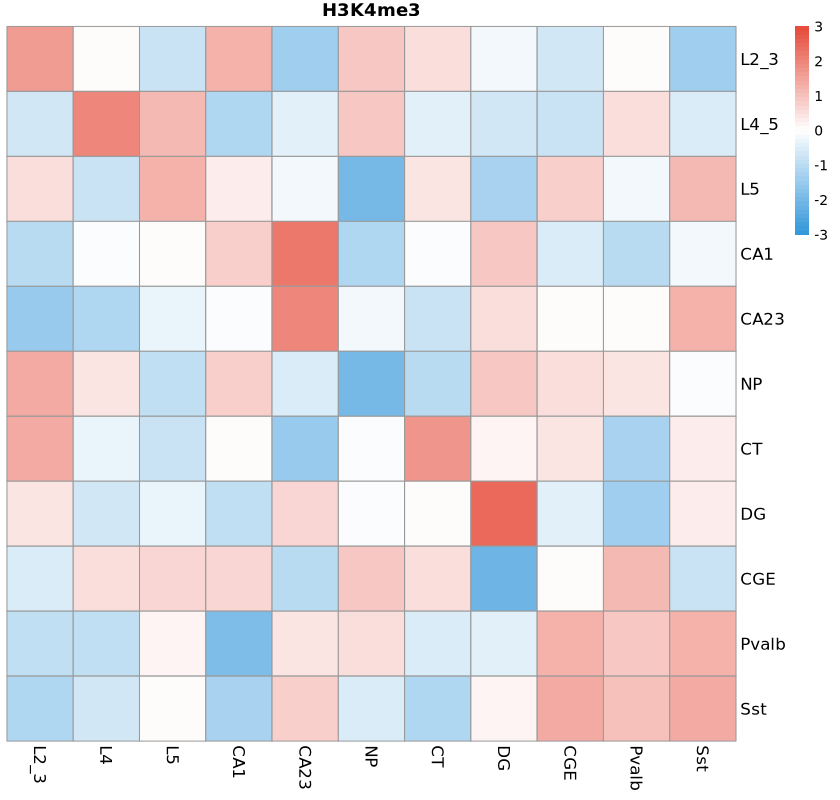

In [58]:
options(repr.plot.width = 8.4, repr.plot.height = 8, repr.plot.res = 100)
pheatmap(
  scaled_heatmap_matrix,
  cluster_rows = FALSE,
  cluster_cols = FALSE,
  color = colorRampPalette(c("#3498db", "white", "#e74c3c"))(50),
  main = "H3K4me3",
  fontsize_row = 12,
  fontsize_col = 12,
  breaks = seq(-3, 3, length.out = 51)
)

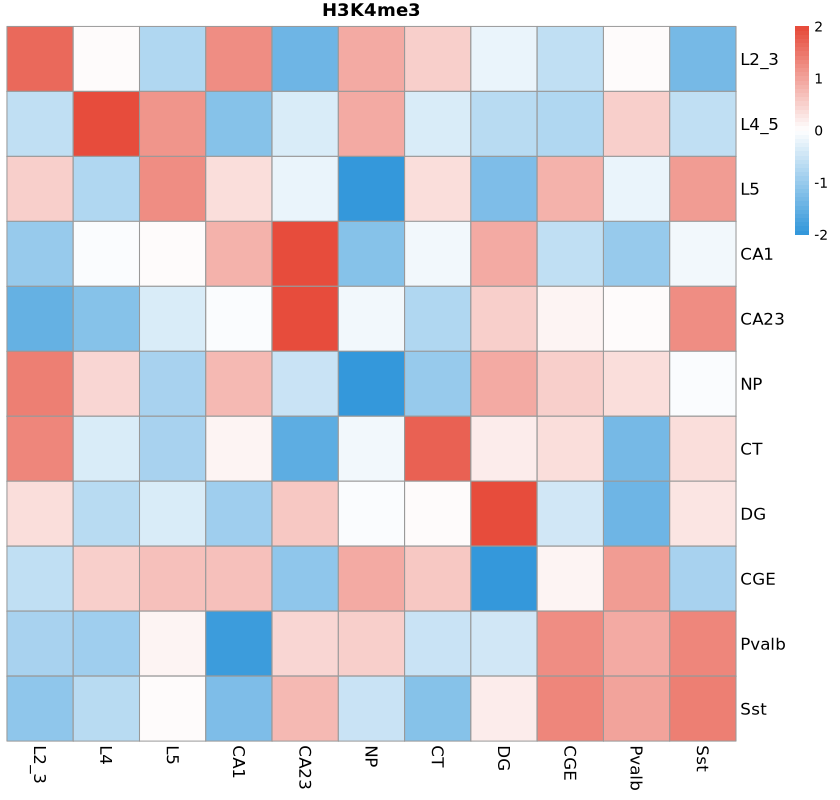

In [59]:
options(repr.plot.width = 8.4, repr.plot.height = 8, repr.plot.res = 100)
pheatmap(
  scaled_heatmap_matrix,
  cluster_rows = FALSE,
  cluster_cols = FALSE,
  color = colorRampPalette(c("#3498db", "white", "#e74c3c"))(50),
  main = "H3K4me3",
  fontsize_row = 12,
  fontsize_col = 12,
  breaks = seq(-2, 2, length.out = 51)
)

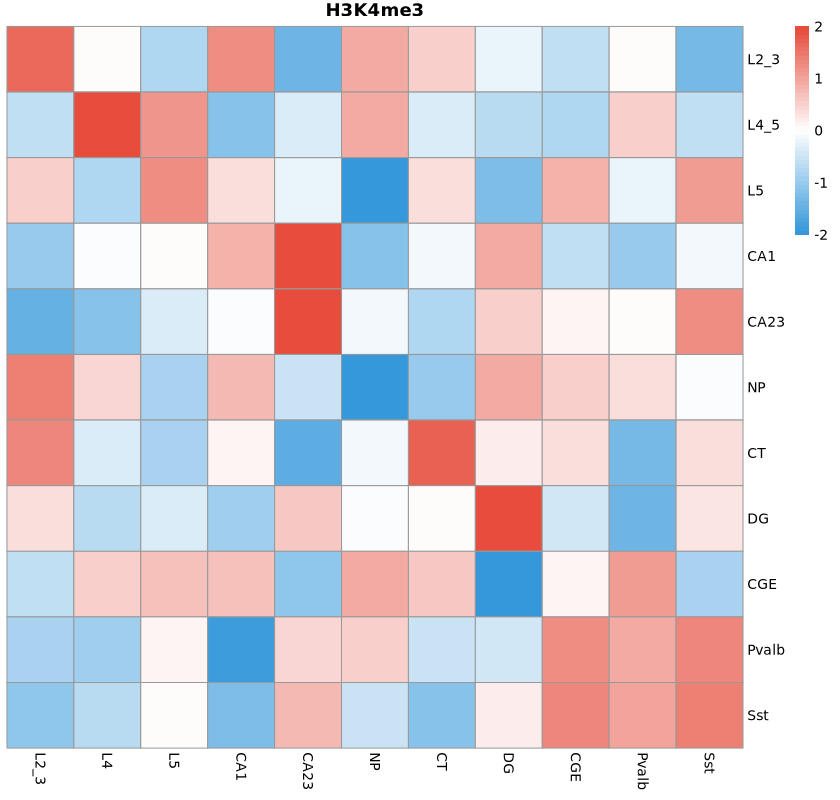

In [60]:
p1 <- pheatmap(
  scaled_heatmap_matrix,
  cluster_rows = FALSE,
  cluster_cols = FALSE,
  color = colorRampPalette(c("#3498db", "white", "#e74c3c"))(50),
  main = "H3K4me3",
  fontsize_row = 10,
  fontsize_col = 10,
  breaks = seq(-2, 2, length.out = 51)
)

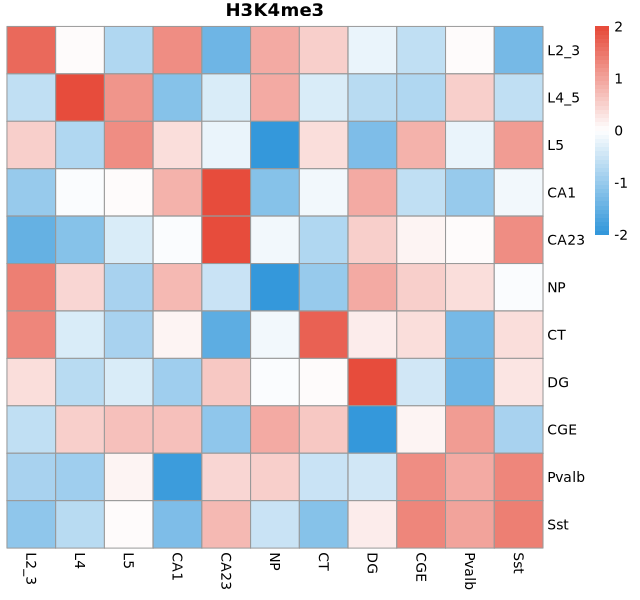

In [61]:
options(repr.plot.width = 6.4, repr.plot.height = 6, repr.plot.res = 100)
p1

In [62]:
pdf("../output/09-H3K4me3_modification_in_hyperDHMR_merge.pdf",width = 6.4,height = 6)
p1
dev.off()

png 
  2

In [ ]:
# Finished!